<a href="https://colab.research.google.com/github/weixisee/COMP3931_Individual_Project/blob/main/notebook/2_3_BinaryBaseline_Atelactasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/IndividualProject/src")

In [ ]:
from evaluation import youden_threshold, gender_disparity, auc_by_sex

In [ ]:
BASE_DIR = "/content/drive/MyDrive/IndividualProject/cxr"

In [ ]:
# import the required libraries
import numpy as np
import pandas as pd
import os
import ast

In [ ]:
processed_df = pd.read_csv(BASE_DIR + "/processed_data_v3.csv")
processed_df.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0


Retrive the train, validation, test splits.

In [ ]:
# read the images in the train set
with open(BASE_DIR + "/splits/train.txt", "r") as f:
    train_list = [image_filepath.strip() for image_filepath in f]

# retrieve the entries in the train split and convert them into a DataFrame
train_df = processed_df[processed_df["filepath"].isin(train_list)]

# repeat the same process for validation set
with open(BASE_DIR + "/splits/val.txt", "r") as f:
    val_list = [image_filepath.strip() for image_filepath in f]

val_df = processed_df[processed_df["filepath"].isin(val_list)]

# repeat the same for test set
with open(BASE_DIR + "/splits/test.txt", "r") as f:
    test_list = [image_filepath.strip() for image_filepath in f]

test_df = processed_df[processed_df["filepath"].isin(test_list)]


In [ ]:
pd.crosstab(
    processed_df["tasks/atelectasis_label"],
    processed_df["split"],
    normalize="index"
)

split,test,train,val
tasks/atelectasis_label,,,
0,0.221925,0.659689,0.118386
1,0.283675,0.612683,0.103642


In [ ]:
print(processed_df.groupby('split')['tasks/atelectasis_label'].value_counts(normalize=True))

split  tasks/atelectasis_label
test   0                          0.871894
       1                          0.128106
train  0                          0.903543
       1                          0.096457
val    0                          0.908571
       1                          0.091429
Name: proportion, dtype: float64


In [ ]:
val_df['tasks/atelectasis_label'].value_counts()

,count
tasks/atelectasis_label,
0,11905
1,1198


In [ ]:
test_df['tasks/atelectasis_label'].value_counts()

,count
tasks/atelectasis_label,
0,22317
1,3279


In [ ]:
print(train_df["patient sex"].value_counts(normalize=True))
print(val_df["patient sex"].value_counts(normalize=True))
print(test_df["patient sex"].value_counts(normalize=True))


patient sex
M    0.55762
F    0.44238
Name: proportion, dtype: float64
patient sex
M    0.573685
F    0.426315
Name: proportion, dtype: float64
patient sex
M    0.581419
F    0.418581
Name: proportion, dtype: float64


In [ ]:
print(train_df["tasks/atelectasis_label"].mean())
print(val_df["tasks/atelectasis_label"].mean())
print(test_df["tasks/atelectasis_label"].mean())


0.09645741681535255
0.09142944363886132
0.12810595405532113


# Baseline Training

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import h5py
import torch.nn.functional as F
from PIL import Image
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, recall_score

In [ ]:
# reference: https://github.com/mvsjober/pytorch-hdf5/blob/master/pytorch_dvc_cnn.py on how to read hdf5 with pytorch
class ChestXRayDataset(Dataset):

    def __init__(self, df, labels_col, hdf5_path, transform=None):
        self.df = df
        self.labels_col = labels_col
        self.hdf5_path = hdf5_path
        self.transform = transform

        self.h5 = h5py.File(self.hdf5_path, "r")
        self.images = self.h5["images"]

        # self.age_map = {'<40': 0, '40-65': 1, '>65': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        original_index = self.df.index[idx]

        img = self.images[original_index]

        img = torch.tensor(img, dtype=torch.float32)

        if img.max() > 1:
            img = img / 255.0

        img = img.unsqueeze(0).repeat(3,1,1)

        if self.transform:
            img = self.transform(img)

        # disease
        y = float(self.df.iloc[idx][self.labels_col])
        label = torch.tensor([y], dtype=torch.float32)

        # sex
        sex = torch.tensor(self.df.iloc[idx]['tasks/patient sex'], dtype=torch.float32)

        # age
        raw_age = self.df.iloc[idx]['patient_age']

        if raw_age >= 50:
          age_binary = 1
        else:
          age_binary = 0

        age = torch.tensor(age_binary, dtype=torch.long)

        # # 2. Logic to determine which group it belongs to
        # if raw_age < 40:
        #     age_str = '<40'
        # elif 40 <= raw_age <= 65:
        #     age_str = '40-65'
        # else:
        #     age_str = '>65'

        # age_idx = torch.tensor(self.age_map[age_str], dtype=torch.long)

        return img, label, sex, age


Peform data augmentation

In [ ]:
# data augmentation process
from torchvision import transforms

# transform function for train set
train_transform = transforms.Compose([
    # perform horizontal flip, rotation and normalize
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

]
)

# trasform function for validation set
valid_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transform function for test set
test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
HDF5_PATH = "/content/drive/MyDrive/IndividualProject/cxr/images.hdf5"

train_dataset = ChestXRayDataset(
    df = train_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = train_transform
)

valid_dataset = ChestXRayDataset(
    df = val_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = valid_transform
)

test_dataset = ChestXRayDataset(
    df = test_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = test_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# pos_weight
pos = float((train_df["tasks/atelectasis_label"] == 1).sum())
neg = float((train_df["tasks/atelectasis_label"] == 0).sum())
pos_weight = torch.tensor([neg/ max(pos,1.0)], device =DEVICE)

# using binary cross entropy with logits loss
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

num_features = model.classifier.in_features
# model.classifier = nn.Linear(num_features, 1)
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
model = model.to(DEVICE)

learning_rate = 5e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

Device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 67.8MB/s]


In [ ]:
from tqdm import tqdm
def train_one_epoch(model, loader, criterion, optimizer, device):
  # use_amp = device.type == "cuda"

  model.train()
  training_loss = 0.0
  loop = tqdm(loader, desc="Training", leave=False)

  for images, labels in loop:
    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    # with autocast(device_type='cuda'):
      # forward pass
    outputs = model(images)
      # compute the loss
    loss = criterion(outputs, labels)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    training_loss += loss.item()

  avg_training_loss = training_loss/len(loader)

  return avg_training_loss

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()
    validation_loss = 0.0
    all_preds = []
    all_labels = []

    # disable gradient calculation
    with torch.no_grad():
      loop = tqdm(loader, desc="Validation", leave=False)

      for images, labels, *_ in loop:
          images = images.to(device, non_blocking=True)
          labels = labels.to(device, non_blocking=True)

          outputs = model(images)
          loss = criterion(outputs, labels)

          validation_loss += loss.item()

          all_preds.append(torch.sigmoid(outputs).cpu())
          all_labels.append(labels.cpu())


    avg_validation_loss = validation_loss / len(loader)
    all_preds = torch.cat(all_preds).numpy().reshape(-1)
    all_labels = torch.cat(all_labels).numpy().reshape(-1)

    # compute the auc score directly
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else np.nan

    return avg_validation_loss, all_preds, all_labels, auc


In [ ]:
def save_checkpoint(epoch, model, optimizer, learning_rate, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'learning_rate': learning_rate
    }
    torch.save(checkpoint, filename)

Main Training Loop

In [ ]:
from datetime import datetime
EPOCHS = 30
best_val = -1.0
patience = 5
min_delta = 0.001
epochs_no_improve = 0
training_loss, validation_loss, validation_auc = [], [], []

# save for model checkpoint
for epoch in range(1, EPOCHS+1):
  #  scaler
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_preds, val_labels, val_auc = validate(model, valid_loader, criterion, DEVICE)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)
    validation_auc.append(val_auc)

    scheduler.step(val_auc if not np.isnan(val_auc) else -1.0)

    print(f"Epoch {epoch}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    # implement early stopping
    if not np.isnan(val_auc) and val_auc > best_val + min_delta:
        best_val = val_auc
        best_epoch = epoch
        epochs_no_improve = 0
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        torch.save(model.state_dict(), f"/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis_{timestamp}.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping: no val AUC improvement for {patience} epochs.")
            break

    save_checkpoint(epoch, model, optimizer, learning_rate, f"checkpoint_epoch_{epoch}.pth")


Epoch 1/30 | Train loss: 1.0509 | Val loss: 1.1270 | Val AUC: 0.7579


Epoch 2/30 | Train loss: 1.0347 | Val loss: 1.0242 | Val AUC: 0.7634


Epoch 3/30 | Train loss: 1.0321 | Val loss: 1.0229 | Val AUC: 0.7770


Epoch 4/30 | Train loss: 1.0134 | Val loss: 1.0131 | Val AUC: 0.7799


Epoch 5/30 | Train loss: 1.0074 | Val loss: 0.9817 | Val AUC: 0.8008


...

Epoch 19/30 | Train loss: 0.8978 | Val loss: 0.9425 | Val AUC: 0.8099


Epoch 20/30 | Train loss: 0.8930 | Val loss: 0.9186 | Val AUC: 0.8233


Epoch 21/30 | Train loss: 0.8905 | Val loss: 0.9344 | Val AUC: 0.8196


Epoch 22/30 | Train loss: 0.8622 | Val loss: 0.9292 | Val AUC: 0.8223


Epoch 23/30 | Train loss: 0.8526 | Val loss: 0.9372 | Val AUC: 0.8219
Early stopping: no val AUC improvement for 5 epochs.


In [ ]:
# save the best result
import json
import os
from datetime import datetime

SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create training history dictionary
training_history = {
    'model_name': 'baseline_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'hyperparameters': {
        'epochs': EPOCHS,
        'batch_size': 64,
        'learning_rate': learning_rate,
        'weight_decay': 1e-4,
        'optimizer': 'Adam',
        'scheduler': 'ReduceLROnPlateau',
        'patience': patience,
        'pos_weight': float(pos_weight.cpu().item()) if torch.is_tensor(pos_weight) else float(pos_weight)
    },
    'dataset_sizes': {
        'train': len(train_df),
        'validation': len(val_df),
        'test': len(test_df)
    },
    'training_curves': {
        'epochs': list(range(1, len(training_loss) + 1)),
        'train_loss': [float(x) for x in training_loss],
        'val_loss': [float(x) for x in validation_loss],
        'val_auc': [float(x) for x in validation_auc]
    },
    'best_model': {
        'epoch': best_epoch if 'best_epoch' in locals() else int(np.argmax(validation_auc)) + 1,
        'val_auc': float(max(validation_auc)),
        'val_loss': float(validation_loss[np.argmax(validation_auc)])
    },
    'early_stopping': {
        'triggered': epochs_no_improve >= patience,
        'stopped_at_epoch': len(training_loss)
    }
}

# Save as JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
history_file = f"{SAVE_DIR}/baseline_training_history_atelectasis_{timestamp}.json"
with open(history_file, 'w') as f:
    json.dump(training_history, f, indent=4)

print(f"Training history saved to {history_file}")

# Also save a summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total epochs trained: {len(training_loss)}")
print(f"Best epoch: {training_history['best_model']['epoch']}")
print(f"Best validation AUC: {training_history['best_model']['val_auc']:.4f}")
print(f"Early stopping: {'Yes' if training_history['early_stopping']['triggered'] else 'No'}")
print("="*60)

Training history saved to /content/drive/MyDrive/IndividualProject/results/baseline_training_history_atelectasis_20260227_190339.json

TRAINING SUMMARY
Total epochs trained: 23
Best epoch: 18
Best validation AUC: 0.8252
Early stopping: Yes


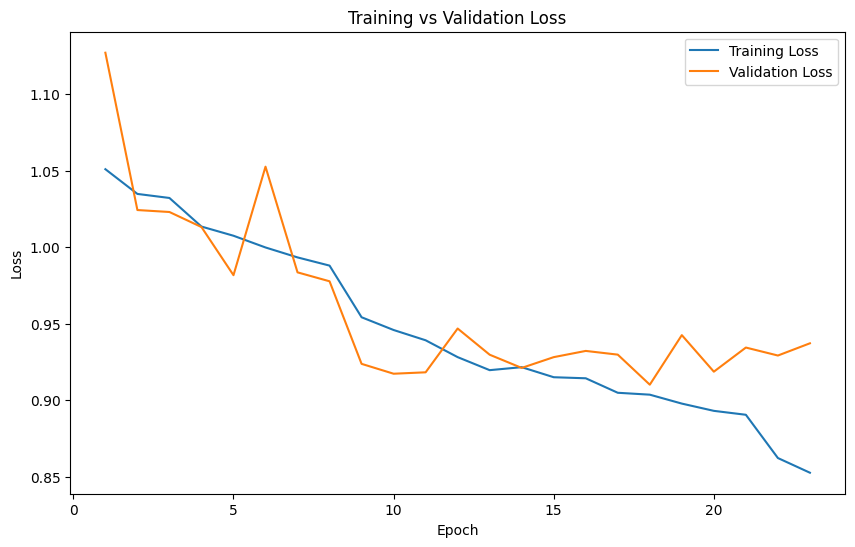

In [ ]:
# plot training_loss  v.s. validation loss
import matplotlib.pyplot as plt

total_epochs = len(training_loss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, total_epochs+1), training_loss, label="Training Loss")
plt.plot(range(1, total_epochs+1), validation_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/training_vs_validation_loss_{timestamp}.png")
plt.show()

/tmp/ipython-input-236/3070032070.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


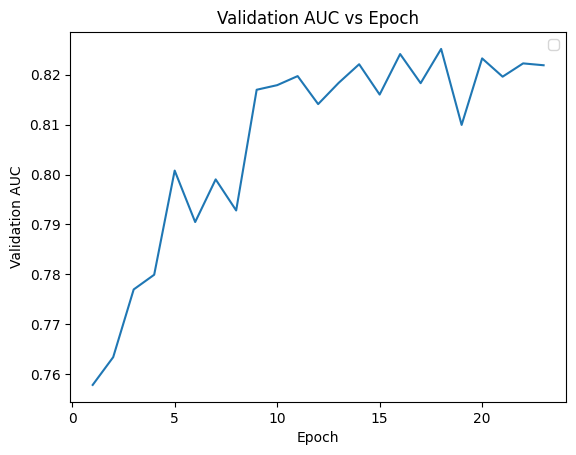

In [ ]:
plt.figure()
plt.plot(range(1, total_epochs+1), validation_auc)

plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC vs Epoch")
plt.legend()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/validation_auc_vs_epoch_{timestamp}.png")
plt.show()

In [ ]:
np.save(BASE_DIR + f"/training_loss_atelectasis_{timestamp}.npy", training_loss)
np.save(BASE_DIR + f"/validation_loss_atelectasis_{timestamp}.npy", validation_loss)
np.save(BASE_DIR + f"/validation_auc_atelectasis_{timestamp}.npy", validation_auc)

# Evaluation


In [ ]:
def age_disparity(y_prob, y_true, df, threshold):

  disparities = {}

  y_pred = (y_prob >= threshold).astype(int)

  young = (df['patient_age'] < 50).to_numpy()
  old = (df['patient_age'] >= 50).to_numpy()

  young_true = y_true[young]
  young_pred = y_pred[young]

  old_true = y_true[old]
  old_pred = y_pred[old]

  young_tpr = recall_score(young_true, young_pred)
  old_tpr = recall_score(old_true, old_pred)

  tpr_disparity = old_tpr - young_tpr

  disparities["atelectasis"] = {
    'tpr_young': round(float(young_tpr), 4),
    'tpr_old': round(float(old_tpr), 4),
    'tpr_disparity': round(float(tpr_disparity), 4),
    'young_samples': int(young.sum()),
    'old_samples': int(old.sum()),
    'total_samples': int(len(y_pred))
  }

  return disparities

In [ ]:
def auc_by_age(y_prob, y_true, df):

    results = {}

    young = (df['patient_age'] < 50).to_numpy()
    old = (df['patient_age'] >= 50).to_numpy()

    young_true = y_true[young]
    young_prob = y_prob[young]

    old_true = y_true[old]
    old_prob = y_prob[old]

    auc_young = roc_auc_score(young_true, young_prob)
    auc_old = roc_auc_score(old_true, old_prob)

    auc_gap = abs(auc_old - auc_young)

    results["atelectasis"] = {
    "auc_young": round(float(auc_young), 4),
    "auc_old": round(float(auc_old), 4),
    "auc_gap": round(float(auc_gap), 4)
  }


    return results

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np
# load the best model and apply it on the test set
BEST_MODEL_PATH =  "/content/drive/MyDrive/IndividualProject/best_model_binary_atelectasis.pth"

# recreate the model
model = models.densenet121(weights=None)
num_features = model.classifier.in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
model = model.to(DEVICE)
best_model = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_model)
model.eval()

val_loss, val_probs, val_labels, val_auc = validate(model, valid_loader, criterion, DEVICE)

# compute Youden's Index
best_threshold_youden = youden_threshold(val_labels, val_probs)
print("Best threshold: ", best_threshold_youden)

test_loss, test_probs, test_labels, test_auc = validate(model, test_loader, criterion, DEVICE)

# print out the result
print(f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")


# compute tpr
test_gender_gap = gender_disparity(test_probs, test_labels, test_df, threshold=best_threshold_youden)
print("Gender gap:", test_gender_gap)

test_age_gap = age_disparity(test_probs, test_labels, test_df, threshold=best_threshold_youden)
print("Age gap:", test_age_gap)

test_auc_by_sex = auc_by_sex(test_probs, test_labels, test_df)
print("AUC by sex:", test_auc_by_sex)

test_auc_by_age = auc_by_age(test_probs, test_labels, test_df)
print("AUC by age:", test_auc_by_age)


Best threshold:  0.54376554


Test Loss: 1.1993 | Test AUC: 0.7605
Gender gap: {'task': {'tpr_male': 0.7698329853862212, 'tpr_female': 0.7197358767424799, 'tpr_disparity': -0.050097108643741395, 'male_samples': 14882, 'female_samples': 10714}}
Age gap: {'atelectasis': {'tpr_young': 0.6969, 'tpr_old': 0.7901, 'tpr_disparity': 0.0932, 'young_samples': 13167, 'old_samples': 12429, 'total_samples': 25596}}
AUC by sex: {'task': {'auc_male': 0.7733668182112395, 'auc_female': 0.7414916252615745, 'auc_gap': 0.03187519294966501}}
AUC by age: {'atelectasis': {'auc_young': 0.7723, 'auc_old': 0.7446, 'auc_gap': 0.0277}}


In [ ]:
import json
import pickle
import pandas as pd
from datetime import datetime

# ===== Save Results to Drive =====
SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create results dictionary
baseline_results = {
    'model_name': 'baseline_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'dataset_size': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'test_metrics': {
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(best_threshold_youden)
    },
    'fairness_metrics': {
        'tpr_male': test_gender_gap['atelectasis']['tpr_male'],
        'tpr_female': test_gender_gap['atelectasis']['tpr_female'],
        'tpr_disparity': test_gender_gap['atelectasis']['tpr_disparity'],
        'auc_male': test_auc_by_sex['atelectasis']['auc_male'],
        'auc_female': test_auc_by_sex['atelectasis']['auc_female'],
        'auc_gap': test_auc_by_sex['atelectasis']['auc_gap'],
        'age_tpr': test_age_gap,
        'age_auc': test_auc_by_age
    },
    'sample_distribution': {
        'male_samples': test_gender_gap['atelectasis']['male_samples'],
        'female_samples': test_gender_gap['atelectasis']['female_samples'],
        'total_samples': test_gender_gap['atelectasis']['total_samples']
    }
}

# Save as JSON (human-readable)
with open(f"{SAVE_DIR}/baseline_results_atelectasis_youden_{timestamp}.json", 'w') as f:
    json.dump(baseline_results, f, indent=4)
print(f"Results saved to {SAVE_DIR}/baseline_results_atelectasis_youden_{timestamp}.json")

KeyError: 'atelectasis'

In [ ]:
from sklearn.metrics import precision_recall_curve

def find_best_f1_threshold(y_true, y_prob):
    # Calculate precision and recall for all possible thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # Calculate F1 score for each threshold
    # Note: precision_recall_curve returns one more value for precision/recall than thresholds
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)

    # Locate the index of the highest F1 score
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    return best_threshold, best_f1

In [ ]:
# compute maximizing f1
best_threshold_f1, _ = find_best_f1_threshold(val_labels, val_probs)
print("Best threshold: ", best_threshold_f1)

test_loss, test_probs, test_labels, test_auc = validate(model, test_loader, criterion, DEVICE)

# print out the result
print(f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")


# compute tpr
test_gender_gap = gender_disparity(test_probs, test_labels, test_df, threshold=best_threshold_f1)
print("Gender gap:", test_gender_gap)

test_age_gap = age_disparity(test_labels, test_probs, test_df, threshold=best_threshold_f1)
print("Age gap:", test_age_gap)

test_auc_by_sex = auc_by_sex(test_probs, test_labels, test_df)
print("AUC by sex:", test_auc_by_sex)

test_auc_by_age = auc_by_age(test_probs, test_labels, test_df)
print("AUC by age:", test_auc_by_age)

Best threshold:  0.6936592


Test Loss: 1.1993 | Test AUC: 0.7605
Gender gap: {'atelectasis': {'tpr_male': 0.5647, 'tpr_female': 0.496, 'tpr_disparity': -0.0688, 'male_samples': 14882, 'female_samples': 10714, 'total_samples': 25596}}
Age gap: {'<40': {'tpr': 0.4582, 'tpr_disparity': -0.0474, 'n_samples': 8411, 'n_pos': 801}, '40-65': {'tpr': 0.577, 'tpr_disparity': 0.0714, 'n_samples': 13492, 'n_pos': 1936}, '>65': {'tpr': 0.5055, 'tpr_disparity': 0.0, 'n_samples': 3693, 'n_pos': 542}}
AUC by sex: {'atelectasis': {'auc_male': 0.7734, 'auc_female': 0.7415, 'auc_gap': 0.0319}}
AUC by age: {'<40': {'auc': 0.7851, 'auc_gap': 0.0303, 'n_samples': 8411, 'n_pos': 801}, '40-65': {'auc': 0.7548, 'auc_gap': 0.0, 'n_samples': 13492, 'n_pos': 1936}, '>65': {'auc': 0.7064, 'auc_gap': -0.0484, 'n_samples': 3693, 'n_pos': 542}}


In [ ]:
male_mask = (test_df['patient sex'] == 'M').to_numpy()
female_mask = (test_df['patient sex'] == 'F').to_numpy()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Male
fpr_male, tpr_male, _ = roc_curve(test_labels[male_mask],
                                  test_probs[male_mask])
auc_male = roc_auc_score(test_labels[male_mask],
                         test_probs[male_mask])

# Female
fpr_female, tpr_female, _ = roc_curve(test_labels[female_mask],
                                      test_probs[female_mask])
auc_female = roc_auc_score(test_labels[female_mask],
                           test_probs[female_mask])

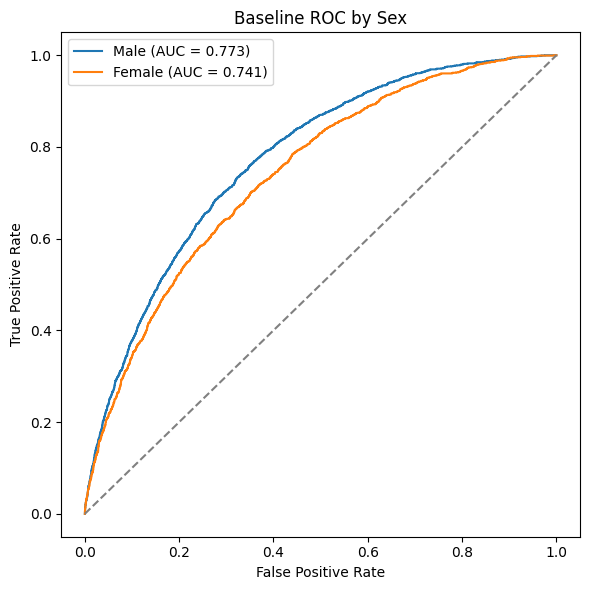

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(fpr_male, tpr_male,
         label=f'Male (AUC = {auc_male:.3f})')

plt.plot(fpr_female, tpr_female,
         label=f'Female (AUC = {auc_female:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline ROC by Sex')
plt.legend()
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/baseline_roc_by_sex_{timestamp}.png")
plt.show()

In [ ]:
import json
import pickle
import pandas as pd
from datetime import datetime

# ===== Save Results to Drive =====
SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create results dictionary
baseline_results = {
    'model_name': 'baseline_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'dataset_size': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'test_metrics': {
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(best_threshold_f1)
    },
    'fairness_metrics': {
        'tpr_male': test_gender_gap['atelectasis']['tpr_male'],
        'tpr_female': test_gender_gap['atelectasis']['tpr_female'],
        'tpr_disparity': test_gender_gap['atelectasis']['tpr_disparity'],
        'auc_male': test_auc_by_sex['atelectasis']['auc_male'],
        'auc_female': test_auc_by_sex['atelectasis']['auc_female'],
        'auc_gap': test_auc_by_sex['atelectasis']['auc_gap'],
        'age_tpr': test_age_gap,
        'age_auc': test_auc_by_age
    },
    'sample_distribution': {
        'male_samples': test_gender_gap['atelectasis']['male_samples'],
        'female_samples': test_gender_gap['atelectasis']['female_samples'],
        'total_samples': test_gender_gap['atelectasis']['total_samples']
    }
}

# Save as JSON (human-readable)
with open(f"{SAVE_DIR}/baseline_results_atelectasis_f1_{timestamp}.json", 'w') as f:
    json.dump(baseline_results, f, indent=4)
print(f"Results saved to {SAVE_DIR}/baseline_results_atelectasis_f1_{timestamp}.json")


Results saved to /content/drive/MyDrive/IndividualProject/results/baseline_results_atelectasis_f1_20260227_190416.json


In [ ]:
# finding the best threshold for computing tpr
def best_threshold(y_true, y_prob, grid_size=501):
  thresholds = np.linspace(0, 1, grid_size)
  best_t, best_f1 = 0.5, -1.0

  for t in thresholds:
    y_pred = (y_prob >=t).astype(int)
    f1 = f1_score(y_true, y_pred)
    if f1 > best_f1:
      best_f1 = f1
      best_t = t

  return best_t, best_f1

In [ ]:
def tpr(y_pred, y_true):
  tp = np.sum(np.logical_and(y_pred == 1, y_true == 1))
  fn = np.sum(np.logical_and(y_pred == 0, y_true == 1))
  if (tp + fn) == 0:
    return np.nan
  return tp / (tp + fn)

# Sex Probing
How much sex information is encoded inside the learn features.

In [ ]:
# define extract features functions
def extract_features(model, loader, device):

  model.eval()
  all_features = []
  all_sex = []

  with torch.no_grad():
    for imgs, _, sex, _ in loader:
      imgs = imgs.to(device)

      features = model.features(imgs)
      features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
      features = features.view(features.size(0), -1)

      all_features.append(features.cpu().numpy())
      all_sex.append(sex.numpy())


  all_features = np.concatenate(all_features, axis=0)
  all_sex = np.concatenate(all_sex, axis=0)
  return all_features, all_sex

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X_train_features, y_train_sex = extract_features(model, train_loader, DEVICE)

X_test_features, y_test_sex = extract_features(model, test_loader, DEVICE)
# y_test_sex = test_df["tasks/patient sex"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

probe = LogisticRegression(max_iter=2000)
probe.fit(X_train_scaled, y_train_sex)

sex_probs = probe.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test_sex, sex_probs)

print("Sex Probe AUC:", round(auc, 4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Sex Probe AUC: 0.784


# Age Probing


In [ ]:
def extract_features_and_age(model, loader, device):
    model.eval()
    all_features = []
    all_ages = []

    with torch.no_grad():
        for imgs, _, _, age_indices in loader:
            imgs = imgs.to(device)

            features = model.features(imgs)
            features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            features = features.view(features.size(0), -1)

            all_features.append(features.cpu().numpy())
            all_ages.append(age_indices.numpy())

    return np.concatenate(all_features, axis=0), np.concatenate(all_ages, axis=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X_train_age, y_train_age = extract_features_and_age(model, train_loader, DEVICE)

X_test_age, y_test_age = extract_features_and_age(model, test_loader, DEVICE)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_age)
X_test_scaled = scaler.transform(X_test_age)

age_probe = LogisticRegression(max_iter=2000)
age_probe.fit(X_train_scaled, y_train_age)

age_probs = age_probe.predict_proba(X_test_scaled)[:, 1]
auc_age = roc_auc_score(y_test_age, age_probs)

print("Age Probe AUC:", round(auc_age, 4))

Age Probe AUC: 0.722


In [ ]:
# save the results
import json
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)
file_path = os.path.join(SAVE_DIR, f"probe_age_{timestamp}.json")

probe_results = {
    "timestamp": timestamp,

    "age_probe_auc": round(auc_age, 4)
}

with open(file_path, "w") as f:
    json.dump(probe_results, f, indent=4)

print("Probe results saved to:", file_path)

Probe results saved to: /content/drive/MyDrive/IndividualProject/results/probe_age_20260228_175253.json


In [ ]:
# save the results
import json
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)
file_path = os.path.join(SAVE_DIR, f"probe_{timestamp}.json")

probe_results = {
    "timestamp": timestamp,
    "sex_probe_auc": round(auc, 4),
    "age_probe_auc": round(auc_age, 4)
}

with open(file_path, "w") as f:
    json.dump(probe_results, f, indent=4)

print("Probe results saved to:", file_path)

Probe results saved to: /content/drive/MyDrive/IndividualProject/results/probe_20260228_110706.json
